In [98]:
import matplotlib.pyplot as plt
def plot_solution(ax: plt.Axes, X: np.ndarray, Y: np.ndarray, label: str = "",
                   xlabel: str="x", ylabel: str ="y", **plot_kwargs) -> None:
    """Plot a single BVP solution on the given axes."""

    ax.plot(X, Y, label=label, **plot_kwargs)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    if label:
        ax.legend()

## Oppgave 1c)

0.0058729530885655535 1071


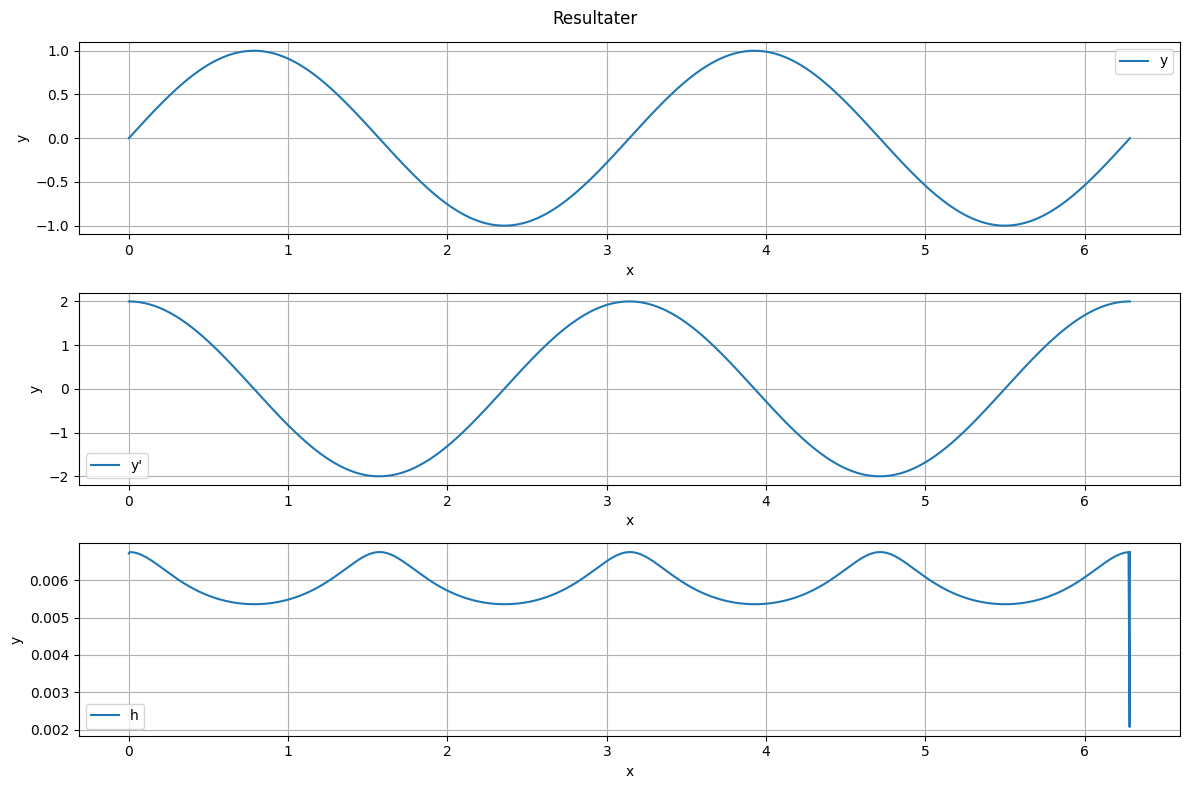

In [ ]:
import numpy as np
def IVP_solver(x_init: float, x_end: float, y_init: np.ndarray,
                h_0: float, tol: float, func, alpha: float) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, float, float]:
    accepted = 0
    rejected = 0
    x_list = []
    y_list = []
    z_list = []
    h_list = []
    x_list.append(x_init)
    y_list.append(y_init)
    h_list.append(h_0)
    k_1 = func(x_list[0],y_list[0])

    while x_list[accepted]<x_end:
        h_list[accepted] = min(h_list[accepted], x_end-x_list[accepted])
        k_2 = func(x_list[accepted]+1/2*h_list[accepted], y_list[accepted] + 1/2*h_list[accepted]*k_1)
        k_3 = func(x_list[accepted] + 3/4*h_list[accepted], y_list[accepted] + 3/4*h_list[accepted]*k_2)
        y_new= np.array(y_list[accepted] + 1/9*h_list[accepted]*(2*k_1+3*k_2+4*k_3))
        x_new = x_list[accepted] + h_list[accepted]
        k_4 = func(x_new,y_new)
        z_new = y_list[accepted] + 1/24*h_list[accepted]*(7*k_1 + 6*k_2 + 8*k_3 + 3*k_4)
        est = np.linalg.norm(y_new-z_new)
        h_new = (alpha * h_list[accepted] * (tol/est)**(1/3))
        if est < tol:
            accepted+=1
            k_1=k_4
            y_list.append(y_new)
            x_list.append(x_new)
            z_list.append(z_new)
            h_list.append(h_new)
        else: 
            h_list[accepted] = h_new
            rejected +=1
    return np.array(x_list), np.array(y_list), np.array(z_list), np.array(h_list), accepted, rejected

def func_1(x,y):
    return  np.array([y[1], -4*np.sin(2*x)]) 

x_array, y_array, z_array, h_array, accepted, rejected = IVP_solver(0, 2*np.pi, np.array([0,2]), 0.001,10**(-7), func_1, 0.8)
fig, axes = plt.subplots(3, 1, figsize=[12,8])
plot_solution(ax=axes[0], X=x_array, Y = y_array[:,0], label = "y")
plot_solution(ax=axes[1], X=x_array, Y = y_array[:,1], label = "y'")
plot_solution(ax=axes[2], X=x_array, Y = h_array, label = "h")
fig.suptitle("Resultater")
plt.tight_layout()
print(np.average(h_array),accepted, rejected)
 

## Oppgave 1d)

[np.float64(0.08497895218577159), np.float64(0.07476206272732314), np.float64(0.062330721183843966), np.float64(0.05462656901569064), np.float64(0.04712412914713824), np.float64(0.034762636960319976), np.float64(0.03071178378201169), np.float64(0.026042316865242908), np.float64(0.021809962732902193), np.float64(0.017114523581870093), np.float64(0.014583564743848311), np.float64(0.012106895136566525), np.float64(0.010014977195928206), np.float64(0.008345353187889823), np.float64(0.0070124087560702415), np.float64(0.005723937617085352), np.float64(0.004788815195113884), np.float64(0.003976074541757193), np.float64(0.0033112034466012937), np.float64(0.002745249041155646), np.float64(0.0022782595759052527), np.float64(0.0019087929305797809), np.float64(0.0015805909568918637), np.float64(0.0013211136106119083), np.float64(0.0011028550757867354), np.float64(0.0009201582382180278), np.float64(0.0007677068890480576), np.float64(0.0006407314389668752), np.float64(0.0005372356048543508), np.floa

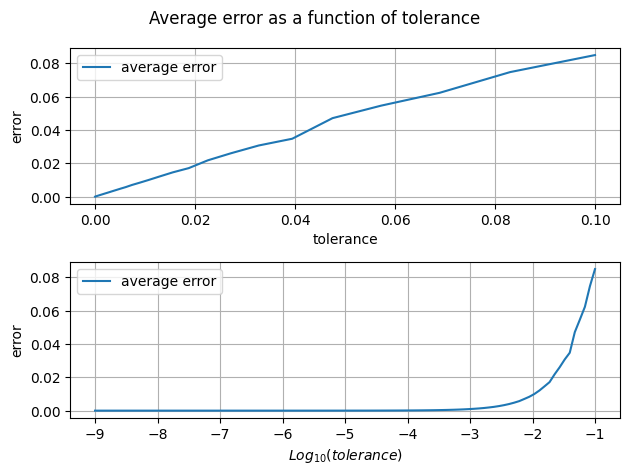

In [112]:
def solution(x):
    return np.sin(2*x)

exponent_array = np.linspace(1,9,100)
error_avg_list = []

for exp in exponent_array:
    x_array, y_array, z_array, h_array, n = IVP_solver(x_init=0, x_end=2*np.pi, y_init=np.array([0,2]), h_0=10**(-3),
                                          tol=10**(-exp), func=func_1, alpha=0.8)
    error_avg = np.linalg.norm(solution(x_array)-y_array[:,0])
    error_avg_list.append(error_avg)
print(error_avg_list)

fig, ax = plt.subplots(2,1)
plot_solution(ax=ax[0], X=10**(-exponent_array), Y = error_avg_list, label = "average error", xlabel="tolerance", ylabel="error")
plot_solution(ax=ax[1], X=-exponent_array, Y = error_avg_list, label = "average error", xlabel="$Log_{10}(tolerance)$", ylabel="error")
fig.suptitle("Average error as a function of tolerance")
fig.tight_layout()

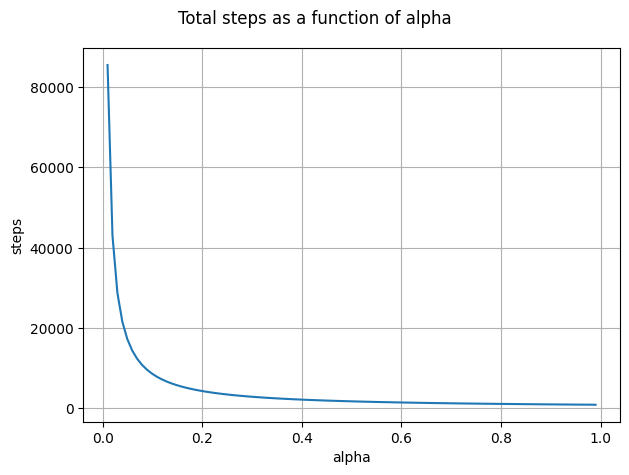

In [113]:
alpha_array = np.linspace(0.01,0.99,100)
step_list = []
for alpha in alpha_array:
    x_array, y_array, z_array, h_array, n = IVP_solver(x_init=0, x_end=2*np.pi, y_init=np.array([0,2]), h_0=10**(-3),
                                          tol=10**(-7), func=func_1, alpha=alpha)
    step_list.append(n)

fig, ax = plt.subplots(1,1)
plot_solution(ax=ax, X=alpha_array, Y = step_list, xlabel="alpha", ylabel="steps")
fig.suptitle("Total steps as a function of alpha")
fig.tight_layout()


## Oppgave 1e)

In [114]:
def sekant_root(g,z_0,z_1, tol):
    z = [z_0, z_1]
    n=1
    while abs(z[n-1]-z[n])>tol:
        z.append((z[n-1]*g(z[n])-z[n]*g(z[n-1]))/(g(z[n])-g(z[n-1])))
        n+=1
    return z[n],n

def g(z):
    return z + np.sin(z) + np.cos(z)

print(sekant_root(g,-20,20,10**(-7)))

(np.float64(-0.45662470456763077), 7)


## Oppgave 1f)

In [115]:
def Shoot(x_init: float, x_end: float, y_0: float,
                h_0: float, tol: float, func, alpha: float, s: float) -> tuple[np.ndarray, np.ndarray]:
    y_init = np.array([y_0,s])
    x_array, y_array, z_array, h_array, n = IVP_solver(x_init=x_init, x_end=x_end,
                                                        y_init=y_init, h_0=h_0, tol=tol,
                                                          func=func, alpha=alpha)
    return y_array[-1], x_array

def shooting_method(x_init: float, x_end: float, y_0: float,
                h_0: float, tol: float, func, alpha: float, s_init: np.ndarray) -> np.ndarray:
    x_arrays = []
    y_arrays = []
    s_list = list(s_init)
    for s in s_init:
        x_array, y_array = Shoot(x_init=x_init, x_end=x_end, y_0=y_0,
                    h_0=h_0, tol=tol, func=func, alpha=alpha, s=s)
        x_arrays.append(x_array)
        y_arrays.append(y_array)
    n=1
    while abs(s_list[n]-s_list[n-1]):
        
        
    

    return 0

IndentationError: expected an indented block after 'while' statement on line 20 (1770290939.py, line 25)